In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [3]:
seed = 42

In [5]:
data = pd.read_csv("Onshore_official_data_incl_prices.csv")

In [9]:
len(data)

70128

In [11]:
# Creating lag features for time-series data

def create_lag_features(data, lag_steps=1):
    for i in range(1, lag_steps + 1):
        data[f'lag_{i}'] = data['volume'].shift(i)

    return data

# Applying lag feature creation to the dataset

lagged_data = create_lag_features(data, lag_steps=1)

# Differencing technique for handling non-stationary data
data['rolling_mean_3'] = data['volume'].rolling(window=3).mean()
data = data.dropna()

In [13]:
data.head()

,Unnamed: 0,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,...,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC,prijs_excl_belastingen,lag_1,rolling_mean_3
2,2017-01-01 02:00:00,20170101,2,202.701006,51.666667,51.000000,10219.473684,98.230769,2017-01-01-03,653746,...,2017-01-01-03,2017-01-01,2017-01,1,861297.084050,13.390476,0.759025,0.0520,677462.0,670180.666667
3,2017-01-01 03:00:00,20170101,3,201.007553,52.333333,54.666667,10211.368421,98.038462,2017-01-01-04,705882,...,2017-01-01-04,2017-01-01,2017-01,1,861302.267903,13.467205,0.819552,0.0410,653746.0,679030.000000
4,2017-01-01 04:00:00,20170101,4,200.325015,52.666667,53.333333,10203.526316,97.461538,2017-01-01-05,716738,...,2017-01-01-05,2017-01-01,2017-01,1,861300.347955,13.482467,0.832158,0.0390,705882.0,692122.000000
5,2017-01-01 05:00:00,20170101,5,199.654969,53.333333,53.333333,10197.684211,96.807692,2017-01-01-06,751456,...,2017-01-01-06,2017-01-01,2017-01,1,861300.216525,13.529769,0.872467,0.0359,716738.0,724692.000000
6,2017-01-01 06:00:00,20170101,6,200.667993,53.666667,52.333333,10191.789474,96.846154,2017-01-01-07,754200,...,2017-01-01-07,2017-01-01,2017-01,1,861300.053175,13.533414,0.875653,0.0350,751456.0,740798.000000


In [15]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-12-25"]
X_test = X[X["date"] >= "2024-12-25"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [17]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(68354, 18)
(68354,)
(155,)
(155, 18)
(68354,)
(155,)


In [25]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage",  
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]

X_train_p = X_train.loc[:, numeric_features]
X_test_p = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_p = preprocessor.fit_transform(X_train_p)
X_test_norm_p = preprocessor.fit_transform(X_test_p)
X_train_p = pd.DataFrame(X_train_norm_p, columns=X_train_p.columns.values, index=X_train_p.index.values)
X_test_p = pd.DataFrame(X_test_norm_p, columns = X_test_p.columns.values, index=X_test_p.index.values)


In [27]:
print(X_train_p.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test_p.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(68354, 9)
(68354,)
(155,)
(155, 9)
(68354,)
(155,)


# Price hourly

In [30]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_p.fit(X_train_p, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_p = cv_XGB_p.best_estimator_
XGB_pred_p = XGB_model_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred_p))

Mean cross-validated score of the best_estimator: 0.9581022500991822
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  773865854309.7234


# Logged version

In [52]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log_p.fit(X_train_p, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log_p = cv_XGB_log_p.best_estimator_
XGB_pred_log_p = XGB_model_log_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log_p))


Mean cross-validated score of the best_estimator: 0.9952831252661642
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  9.409092377027754


In [12]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

61344
8784


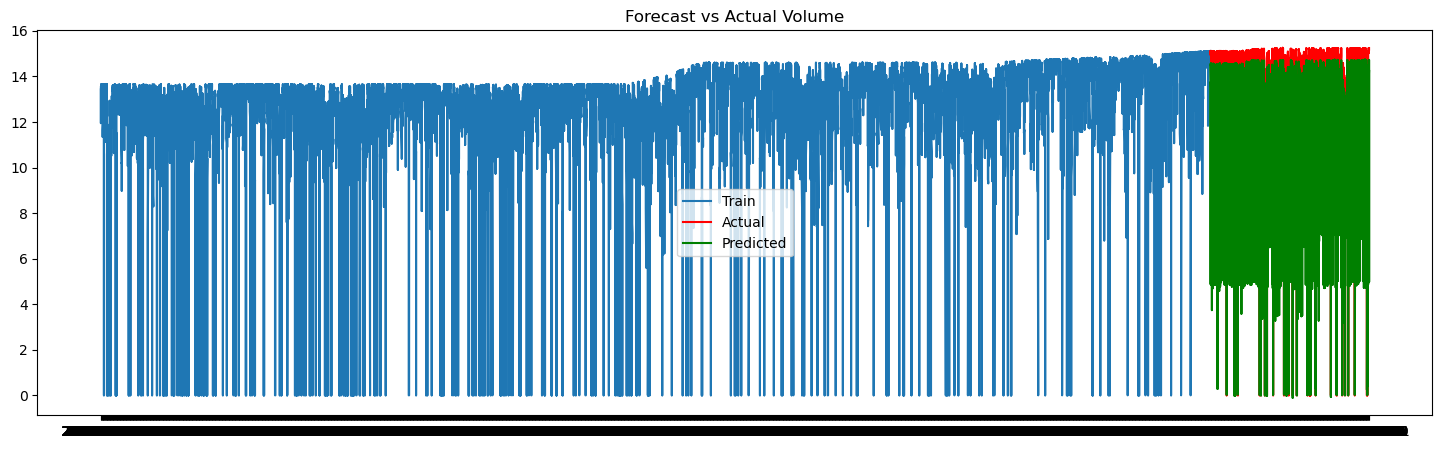

In [13]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train, y_train_log, label="Train")
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [32]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]


# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data



In [34]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 12)
(6, 12)
(90,)
(6,)
(90,)
(6,)


In [36]:
print(X_train_month["prijs_excl_belastingen"].dtype)

float64


In [38]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_month_p = X_train_month.loc[:, numeric_features]
X_test_month_p = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month_p = preprocessor.fit_transform(X_train_month_p)
X_test_norm_month_p = preprocessor.fit_transform(X_test_month_p)


In [40]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month_p, columns=X_train_month_p.columns.values, index=X_train_month_p.index.values)

X_test_month = pd.DataFrame(X_test_norm_month_p, columns = X_test_month_p.columns.values, index=X_test_month_p.index.values)

X_train_month_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,prijs_excl_belastingen,lag_1,rolling_mean_3
month,,,,,,,,,
2017-01,188.675499,38.089348,38.133713,10223.051133,87.285459,0.491594,0.048686,423431.935806,423349.197337
2017-02,167.038790,50.960181,51.001463,10153.188701,85.520033,0.685773,0.037989,590608.577273,590480.152525
2017-03,187.786930,45.598008,45.687166,10154.985158,78.286863,0.487051,0.035393,419427.196721,419406.037341
2017-04,245.535677,39.556065,39.780759,10205.904464,74.810594,0.481488,0.036236,413752.009050,413721.612368
2017-05,169.377392,36.836916,36.938759,10170.260097,73.394675,0.381566,0.035650,329501.753463,329343.982918


In [70]:
print(X_train_month_p.shape)
print(X_test_month_p.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 9)
(6, 9)
(90,)
(6,)
(90,)
(6,)


In [16]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log_p.fit(X_train_month_p, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log_p = cv_XGB_month_log_p.best_estimator_
XGB_pred_month_log_p = XGB_model_month_log_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log_p))

Mean cross-validated score of the best_estimator: 0.5464168419025394
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  0.04189113125219235


In [78]:
x_axis_train_m = db_monthly["year_mon_day"][:len(y_train_month)]
x_axis_test_m = db_monthly["year_mon_day"][len(y_train_month):]
print(len(x_axis_train_m))
print(len(x_axis_test_m))

90
6


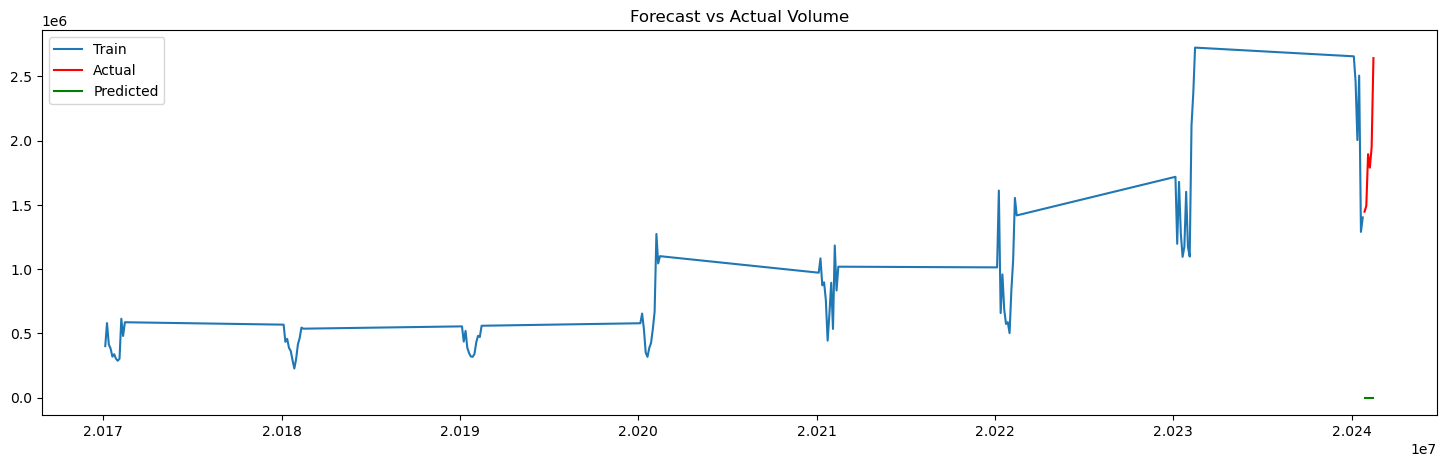

In [20]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_m, y_train_month, label="Train")
plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_log_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [82]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_month_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_p.fit(X_train_month_p, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_p = cv_XGB_month_p.best_estimator_
XGB_pred_month_p = XGB_model_month_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month_p))


Mean cross-validated score of the best_estimator: 0.7951884837090373
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  16273242304.86399


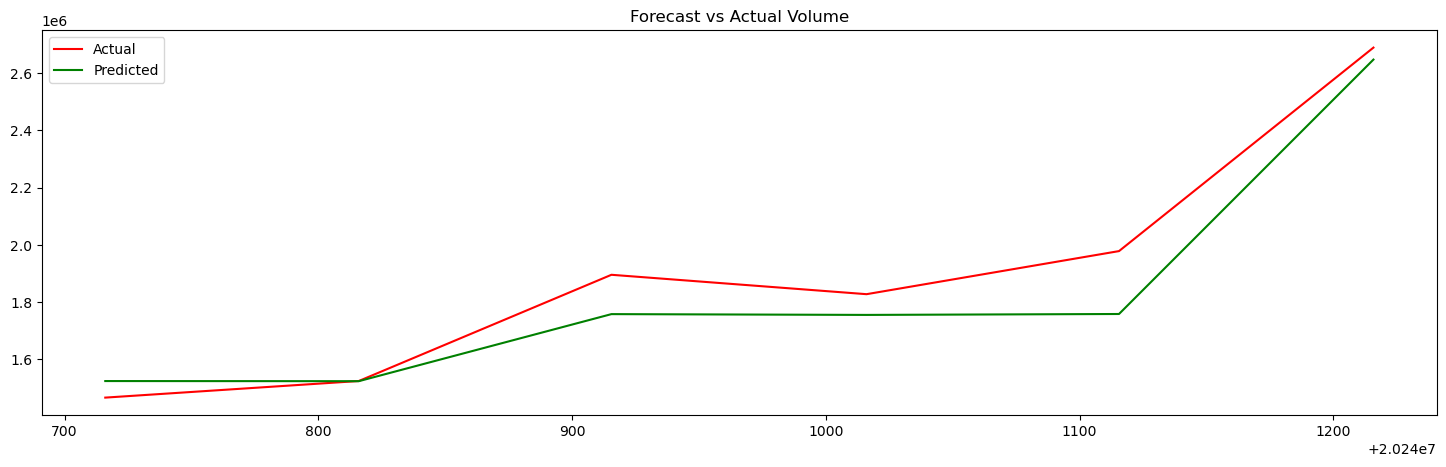

In [80]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

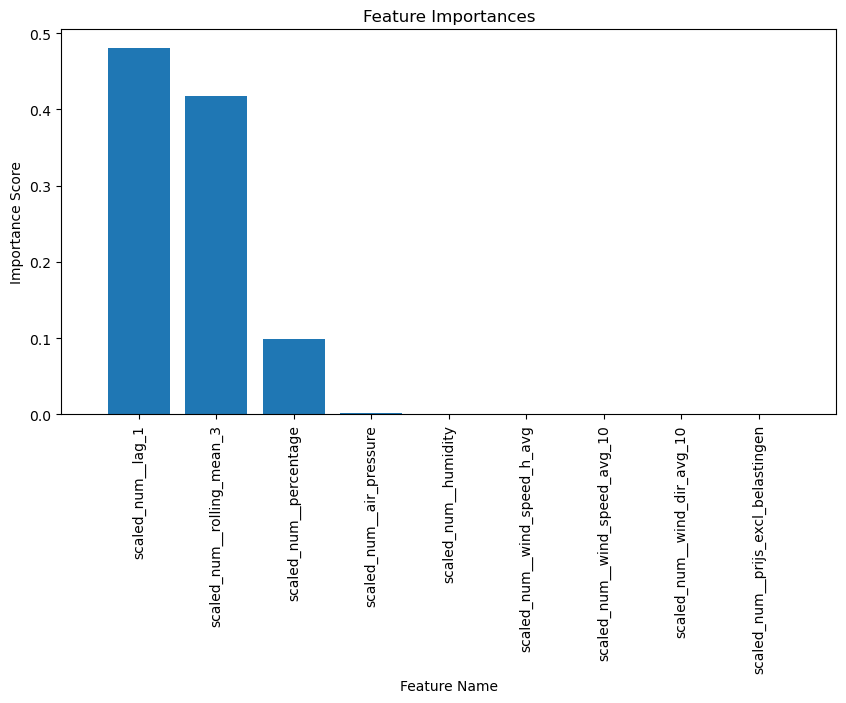

In [74]:
importances = XGB_model_month_p.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

# Weekly

In [46]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)


# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [48]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 11)
(12, 11)
(406,)
(12,)
(406,)
(12,)


In [50]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_week_p = X_train_week.loc[:, numeric_features]
X_test_week_p = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week_p = preprocessor.fit_transform(X_train_week_p)
X_test_norm_week_p = preprocessor.fit_transform(X_test_week_p)

In [52]:
#add feature names back 
X_train_week_p = pd.DataFrame(X_train_norm_week_p, columns=X_train_week_p.columns.values, index=X_train_week_p.index.values)

X_test_week_p = pd.DataFrame(X_test_norm_week_p, columns = X_test_week_p.columns.values, index=X_test_week_p.index.values)

X_train_week_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,prijs_excl_belastingen,lag_1,rolling_mean_3
1,0.729998,0.227910,0.217349,1.466448,0.838863,0.604434,-0.610463,-0.417887,-0.417990
2,1.130892,1.063752,1.053137,-0.593879,1.081014,0.651842,-0.585320,-0.407097,-0.406837
3,-1.539699,-1.753193,-1.771239,2.298914,1.174634,-1.569318,-0.370256,-1.159962,-1.160815
4,-0.634048,-1.171096,-1.166341,1.170334,0.560127,-0.695118,-0.376228,-0.871240,-0.871107
5,-0.482864,-0.087975,-0.095183,-0.787287,1.056134,0.130106,-0.523708,-0.576596,-0.576689


In [54]:
print(X_train_week_p.shape)
print(X_test_week_p.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 9)
(12, 9)
(406,)
(12,)
(406,)
(12,)


In [56]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_p.fit(X_train_week_p, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_p = cv_XGB_week_p.best_estimator_
XGB_pred_week_p = XGB_model_week_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week_p))


Mean cross-validated score of the best_estimator: 0.9646127631992251
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1558129062370.7458


In [27]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log_p.fit(X_train_week_p, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log_p = cv_XGB_week_log_p.best_estimator_
XGB_pred_week_log_p = XGB_model_week_log_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log_p))

Mean cross-validated score of the best_estimator: 0.7254989544061626
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  0.26672512797571235


In [28]:
x_axis_train_w = db_weekly["year_mon_day"][:len(y_train_week)]
x_axis_test_w = db_weekly["year_mon_day"][len(y_train_week):]
print(len(x_axis_train_w))
print(len(x_axis_test_w))

406
12


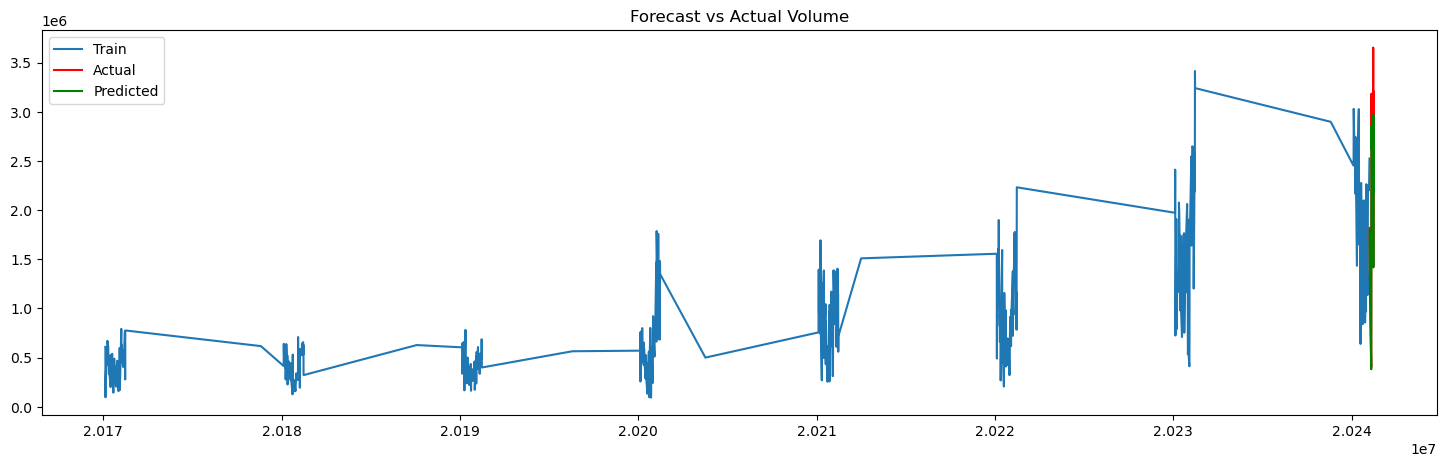

In [29]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_w, y_train_week, label="Train")
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

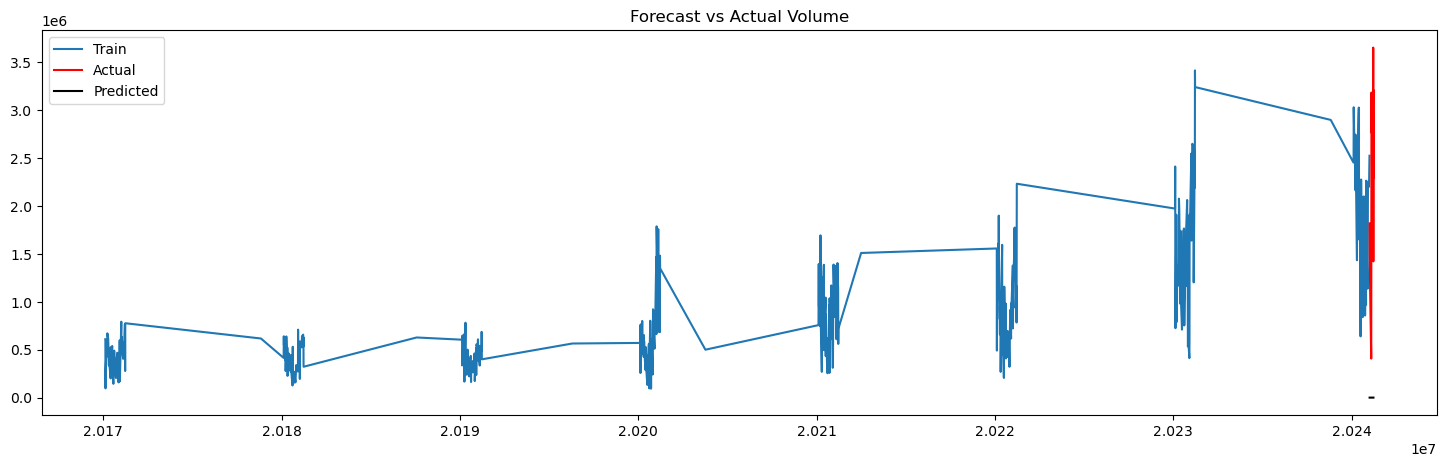

In [32]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train_w, y_train_week, label="Train")
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_log_p, label="Predicted", color='black')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [31]:
XGB_pred_week_log_p[0:5]

array([13.820488, 13.533184, 12.57486 , 11.57271 , 13.687227],
      dtype=float32)

In [33]:
y_test_week_log[0:5]

week_number
407    13.170476
408    13.720689
409    12.947995
410    11.929705
411    13.763364
Name: log_volume, dtype: float64

# Daily

In [58]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_98203/4229511020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date2'] = pd.to_datetime(data['date'], format='ISO8601')


In [60]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 12)
(60, 12)
(2862,)
(60,)
(2862,)
(60,)


In [62]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_day_p = X_train_day.loc[:, numeric_features]
X_test_day_p = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day_p = preprocessor.fit_transform(X_train_day_p)
X_test_norm_day_p = preprocessor.fit_transform(X_test_day_p)

In [64]:
#add feature names back 
X_train_day_p = pd.DataFrame(X_train_norm_day_p, columns=X_train_day_p.columns.values, index=X_train_day_p.index.values)
X_test_day_p = pd.DataFrame(X_test_norm_day_p, columns = X_test_day_p.columns.values, index=X_test_day_p.index.values)
X_train_day_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,prijs_excl_belastingen,lag_1,rolling_mean_3
2017-01-01,0.287676,0.494475,0.492646,0.320080,1.615445,0.346067,-0.501225,-0.377726,-0.376126
2017-01-02,1.297147,-0.547393,-0.545760,0.811394,0.842197,1.001472,-0.429137,-0.117793,-0.119226
2017-01-03,0.817968,1.182771,1.222402,0.663640,0.861673,1.077055,-0.581170,-0.093600,-0.093862
2017-01-04,1.576087,1.388684,1.348513,0.204684,0.056368,1.222620,-0.619000,-0.031555,-0.031619
2017-01-05,-0.666314,-0.773903,-0.802932,1.760883,0.108709,-0.526623,-0.585638,-0.674101,-0.674229


In [66]:
print(X_train_day_p.shape)
print(X_test_day_p.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 9)
(60, 9)
(2862,)
(60,)
(2862,)
(60,)


In [68]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_p.fit(X_train_day_p, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_p = cv_XGB_day_p.best_estimator_
XGB_pred_day_p = XGB_model_day_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day_p))

Mean cross-validated score of the best_estimator: 0.9741203295450708
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  2078499431103.5286


In [40]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log_p.fit(X_train_day_p, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log_p = cv_XGB_day_log_p.best_estimator_
XGB_pred_day_log_p = XGB_model_day_log_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log_p))

Mean cross-validated score of the best_estimator: 0.8290992943911938
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  3.4178218420128954
